# Does the covariance matrix remain positive difinite?

Requires Python ($\geq$ 3.9.18) Kernel

## Aim of the experiment

Applying the Matern-3/2 covariance function is known to be not positive definite on the sphere, when used with the great-circle distance. This comes from the restriction of a function defined on $\mathbb{R}^+$ to a finite domain. However, for the wind gust postprocessing model we are investigating a limited part on the sphere with maximum distances of $\mathcal{O}(10^3)$ km, so that the investigated area is almost flat. Nevertheless, we like to work on the real distances, which is why we selected the geat-circle distance. 

In earlier stages, we experimented with an exponential covariance kernel, which is known to be positive definite on the sphere. However, due to some very short distances between some of the training locations, it led to numerical instabilities. Therefore, we selected a function with a higher smoothness, thereby sacrificing the guarantee of a positive definite matrix.

In this notebook, we ran checks on the resulting covariance matrix, whether it remains positive definite on the domain, where we train SpatBHM, using the coordinates of the training locations and a wide variety of possible parameter values.

## Modules

In [1]:
# import modules
import numpy as np

# plotting
import matplotlib as mpl
import matplotlib.pyplot as plt

# data handling
import pandas as pd

# statistics
import scipy as scp
import scipy.linalg as la

# technical packages
from copy import deepcopy
from tqdm import tqdm
import time
from time import sleep
import sys, os
from datetime import datetime

## Testing functions

In [2]:
def haversine_distance(coord1, coord2, R=6371.0):
    """
    Returns the great circle distance between two points on Earth.
    coord1, coord2: (lon, lat) in degrees
    R: Earth radius in km
    """
    lon1, lat1 = coord1
    lon2, lat2 = coord2

    # degrees -> radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c  # in km

def haversine_distance_matrix(coords, R=6371.0, heights=None, f_z=1.0):
    """
    coords: Nx2 array with (lon, lat) in degrees
    heights: optional, N-dim array with elevation in km
    f_z: scaling factor for height difference
    """
    N = len(coords)
    D = np.zeros((N, N))

    for i in range(N):
        for j in range(i, N):
            d = haversine_distance(coords[i], coords[j], R)
            if heights is not None:
                dz = heights[i] - heights[j]
                d = np.sqrt(d**2 + (f_z*dz)**2)
            D[i,j] = d
            D[j,i] = d  # symmetric
    return D


def matern_32(D, sigma, rho):
    """
    Returns the Matern-3/2 covariance function for a given distance, sill sigma and range rho.
    D: np.ndarray, containing the distances
    sigma: sill, process variance
    rho: range parameter, in km
    """
    C = sigma**2*(1 + np.sqrt(3)*D/rho) * np.exp(-D*np.sqrt(3)/rho)
    return C


def cholesky_test(K):
    """
    Checks, whether the matrix K can be cholesky decomposed, thereby testing whether it is positive definite.
    Returns True, in case the factorization was successful and False in case it was not.
    """
    #print("--- Cholesky / PD Test ---")
    try:
        L = np.linalg.cholesky(K)
        #print("  Cholesky successful. diag(L) min/max:", np.min(np.diag(L)), np.max(np.diag(L)))
        return True#, L
    except np.linalg.LinAlgError:
        # diagnose via Eigenwerte
        #eigs = la.eigvalsh(K)
        #print("  Cholesky failed. min-eig:", np.min(eigs), "max-eig:", np.max(eigs))
        #print("  cond:", np.max(eigs)/np.minimum(np.min(eigs[np.nonzero(eigs)]), 1e-300))
        return False#, None

## Read data and set prior distributions

- use the same priors as used during model training for the manuscript

In [3]:
##################################
# Read training data
#################################

# read station data
stat_info = pd.read_csv('data/used_stations_109.csv', dtype={"Stations_id":str})
z_station = np.array(stat_info.Stationshoehe)
cols = [str(s).zfill(5) for s in stat_info.Stations_id]

# prepare station coordinates for fit (remove verification locations)
x1 = stat_info.geoLaenge.values
x2 = stat_info.geoBreite.values
M = len(cols)
coord = np.zeros((M,2))
coord[:,0] = x1
coord[:,1] = x2

#####################################
# set prior distribution parameters
######################################

# Prior for sills, inverse-gamma(a,b)
sills_prior = np.zeros(2)
sills_prior[0] = 5 # originally 5
sills_prior[1] = 2 # originally 2

# prior for ranges, inverse-gamma(a,b)
ranges_prior = np.zeros(2)
ranges_prior[0] = 1.05 # oriringally 1.05
ranges_prior[1] = 100 # originally 100

# Prior for f, Gamma-distribution
f_prior = np.array([15,0.15])

## Calculate covariance matrix from priors

- Estimate the covariance matrix for the station coordinates, given the great-circle distance, the Matern-3/2 covariance function and random draws for the parameters $f_z$, $\sigma$ and $\rho$ from their prior distributions

In [4]:
# ~~~ careful, execution is computation intensive ~~~
np.random.seed(100)
Ndraw = 10000 # number of draws

# draw 
fzs = scp.stats.gamma.rvs(a=f_prior[0], loc=0, scale=1/f_prior[1], size=Ndraw)
sills = scp.stats.invgamma.rvs(a=sills_prior[0], loc=0, scale=sills_prior[1], size = Ndraw)
ranges = scp.stats.invgamma.rvs(a=ranges_prior[0], loc=0, scale=ranges_prior[1], size = Ndraw)
print(ranges.max())

pos_def_test = []

for i in tqdm(range(Ndraw)):
    D = haversine_distance_matrix(coord,heights=z_station/1000,f_z=fzs[i])
    K = matern_32(D, sills[i], ranges[i])
    pos_def_test.append(cholesky_test(K))

print(np.all(np.array(pos_def_test)==True))

631593.241664474


100%|██████████| 10000/10000 [33:19<00:00,  5.00it/s]

False


### How does the positive definiteness depend on the parameters?


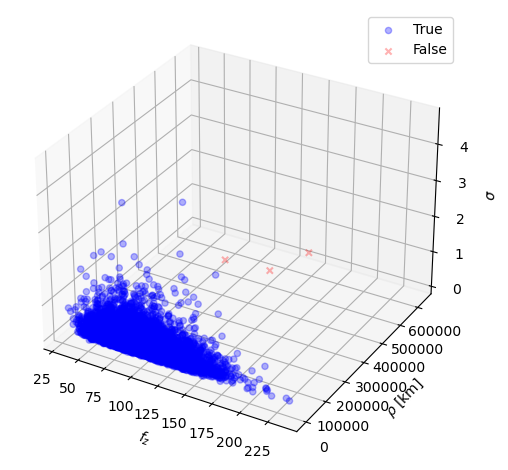

In [5]:
bool_mask = pd.Series(pos_def_test)==True # True/False Array

# 3D Scatterplot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# True Points in blue, False Points in red
ax.scatter(fzs[bool_mask], ranges[bool_mask],sills[bool_mask] ,color='blue', label='True', alpha=0.3)
ax.scatter(fzs[~bool_mask], ranges[~bool_mask], sills[~bool_mask],color='red', marker="x", label='False', alpha=0.3)
#ax.set_zscale('log')

ax.set_xlabel(r'$f_z$')
ax.set_zlabel(r'$\sigma$')
ax.set_ylabel(r"$\rho$ $[\mathrm{km}]$")
ax.legend()
plt.tight_layout()
#plt.savefig("figures/revision/CovMat_pos_def_3d_scatter.pdf")
plt.show()

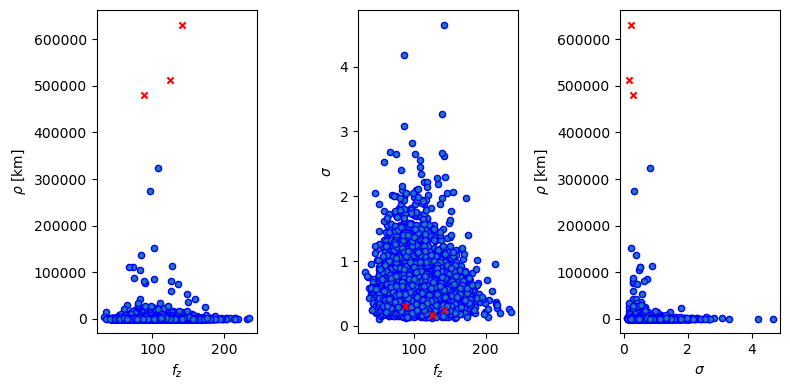

In [6]:
# individual 2D scatterplots for clarity
fig, ax = plt.subplots(1,3,figsize=(8,4))
ax[0].scatter(fzs[bool_mask], ranges[bool_mask], edgecolor='blue', label='True', marker = "o", color=None,s=20)
ax[0].scatter(fzs[~bool_mask], ranges[~bool_mask], color='red', marker="x", label='False',s=20)
ax[0].set_xlabel(r"$f_z$")
ax[0].set_ylabel(r"$\rho$ $[\mathrm{km}]$")

ax[1].scatter(fzs[bool_mask], sills[bool_mask], edgecolor='blue', label='True', marker = "o", color=None,s=20)
ax[1].scatter(fzs[~bool_mask], sills[~bool_mask], color='red', marker="x", label='False',s=20)
ax[1].set_xlabel(r"$f_z$")
ax[1].set_ylabel(r"$\sigma$")

ax[2].scatter(sills[bool_mask], ranges[bool_mask], edgecolor='blue', label='True', marker = "o", color=None,s=20)
ax[2].scatter(sills[~bool_mask], ranges[~bool_mask], color='red', marker="x", label='False',s=20)
ax[2].set_xlabel(r"$\sigma$")
ax[2].set_ylabel(r"$\rho$ $[\mathrm{km}]$")

plt.tight_layout()
#plt.savefig("figures/revision/CovMat_pos_def_2d_scatter.pdf")
plt.show()

- the covariance matrix $K$ is mostly positive definite except for exceptionally large ranges of $\rho>400000$ km, without a clear contribution by $\sigma$ and $f_z$.

## Calculate covariance matrix from posterior

- Estimate the covariance matrix for the station coordinates, given the great-circle distance, the Matern-3/2 covariance function and random draws for the parameters $f_z$, $\sigma$ and $\rho$ from their posterior distributions (i.e. the model fit results)

In [7]:
fit = pd.read_csv("Model_fits/SM_mu0_mu2_f/SM_mu0_mu2_f_complete_fit.csv")[["f","sills.1","ranges.1", "sills.2","ranges.2"]]

fzs = np.tile(fit.f.values,2)
sills = np.concatenate((fit["sills.1"].values, fit["sills.2"].values))
ranges = np.concatenate((fit["ranges.1"].values, fit["ranges.2"].values))

print(f"Maximum range in the posterior sample is {ranges.max():.2f} km.")

pos_def_test = []

for i in tqdm(range(len(fzs))):
    D = haversine_distance_matrix(coord,heights=z_station/1000,f_z=fzs[i])
    K = matern_32(D, sills[i], ranges[i])
    pos_def_test.append(cholesky_test(K))

print(np.all(np.array(pos_def_test)==True))

Maximum range in the posterior sample is 139.24 km.


100%|██████████| 2000/2000 [06:39<00:00,  5.00it/s]

True


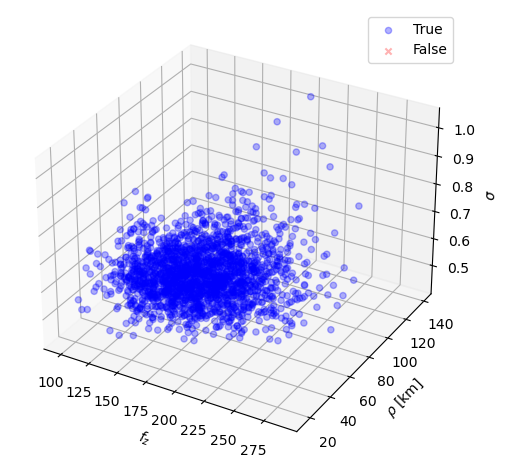

In [8]:
bool_mask = pd.Series(pos_def_test)==True # True/False Array

# 3D Scatterplot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# True Points in blue, False Points in red
ax.scatter(fzs[bool_mask], ranges[bool_mask],sills[bool_mask] ,color='blue', label='True', alpha=0.3)
ax.scatter(fzs[~bool_mask], ranges[~bool_mask], sills[~bool_mask],color='red', marker="x", label='False', alpha=0.3)
#ax.set_zscale('log')

ax.set_xlabel(r'$f_z$')
ax.set_zlabel(r'$\sigma$')
ax.set_ylabel(r"$\rho$ $[\mathrm{km}]$")
ax.legend()
plt.tight_layout()
#plt.savefig("figures/revision/CovMat_pos_def_3d_scatter.pdf")
plt.show()

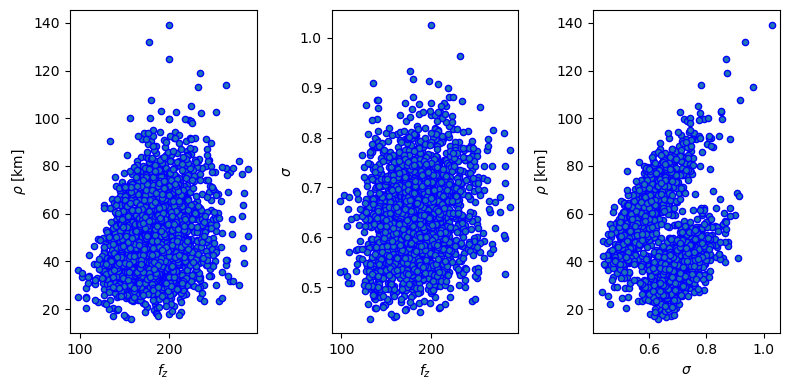

In [9]:
# individual 2D scatterplots for clarity
fig, ax = plt.subplots(1,3,figsize=(8,4))
ax[0].scatter(fzs[bool_mask], ranges[bool_mask], edgecolor='blue', label='True', marker = "o", color=None,s=20)
ax[0].scatter(fzs[~bool_mask], ranges[~bool_mask], color='red', marker="x", label='False',s=20)
ax[0].set_xlabel(r"$f_z$")
ax[0].set_ylabel(r"$\rho$ $[\mathrm{km}]$")

ax[1].scatter(fzs[bool_mask], sills[bool_mask], edgecolor='blue', label='True', marker = "o", color=None,s=20)
ax[1].scatter(fzs[~bool_mask], sills[~bool_mask], color='red', marker="x", label='False',s=20)
ax[1].set_xlabel(r"$f_z$")
ax[1].set_ylabel(r"$\sigma$")

ax[2].scatter(sills[bool_mask], ranges[bool_mask], edgecolor='blue', label='True', marker = "o", color=None,s=20)
ax[2].scatter(sills[~bool_mask], ranges[~bool_mask], color='red', marker="x", label='False',s=20)
ax[2].set_xlabel(r"$\sigma$")
ax[2].set_ylabel(r"$\rho$ $[\mathrm{km}]$")

plt.tight_layout()
#plt.savefig("figures/revision/CovMat_pos_def_2d_scatter.pdf")
plt.show()

- the plots are bimodal, because there are two different spatial fields in the posterior samples. One mode it the GRF for $\mu^0$ and the other one the GRF for $\mu^2$.